##Google Colab

In [14]:
# Instalar PySpark en Colab (solo si no usas Databricks)
!pip install pyspark==3.5.0 -q
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("S5_LimaTaxis") \
    .config("spark.ui.port", "4050") \
    .getOrCreate()
print(f"✅ Spark {spark.version} listo en Colab")

✅ Spark 3.5.0 listo en Colab


##PARTE 1 — EXPLORACIÓN: Carga y perfil del dataset
###Celda 1 — Generar el dataset

In [15]:
# ============================================================
# CELDA 1: Dataset de 10,000 viajes TaxiApp Lima
# ============================================================
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import *

np.random.seed(2026)
N = 10_000

distritos = [
    "Miraflores", "San Isidro", "Barranco", "Surco", "San Borja",
    "SJL",        "Comas",      "Los Olivos","Ate",   "Villa El Salvador",
    "Callao",     "Independencia","La Victoria","Pueblo Libre","Jesús María"
]
turnos   = ["mañana", "tarde", "noche", "madrugada"]
metodos  = ["efectivo", "yape",   "tarjeta",  "contra_app"]
estados  = ["completado","completado","completado","cancelado","incidente"]

data = {
    "id_viaje":      [f"TX{i:07d}" for i in range(1, N+1)],
    "fecha":         pd.date_range("2025-09-01", periods=N, freq="1h")
                        .strftime("%Y-%m-%d").tolist(),
    "turno":         np.random.choice(turnos,    N, p=[.30, .35, .25, .10]).tolist(),
    "origen":        np.random.choice(distritos, N).tolist(),
    "destino":       np.random.choice(distritos, N).tolist(),
    "distancia_km":  np.round(np.random.exponential(9, N).clip(1, 45), 2).tolist(),
    "duracion_min":  np.random.randint(5, 120, N).tolist(),
    "tarifa_soles":  np.round(np.random.uniform(7, 95, N), 2).tolist(),
    "propina_soles": np.round(np.random.choice(
                        [0.0, 0.0, 0.0, 2.0, 5.0, 10.0], N, p=[.5, .1, .1, .15, .1, .05]), 2).tolist(),
    "metodo_pago":   np.random.choice(metodos, N, p=[.25, .40, .25, .10]).tolist(),
    "id_conductor":  [f"CON{np.random.randint(1, 200):04d}" for _ in range(N)],
    "rating":        np.round(np.random.normal(4.15, 0.55, N).clip(1, 5), 1).tolist(),
    "estado":        np.random.choice(estados, N, p=[.78, .07, .03, .10, .02]).tolist(),
}

schema = StructType([
    StructField("id_viaje",     StringType()),
    StructField("fecha",        StringType()),
    StructField("turno",        StringType()),
    StructField("origen",       StringType()),
    StructField("destino",      StringType()),
    StructField("distancia_km", DoubleType()),
    StructField("duracion_min", IntegerType()),
    StructField("tarifa_soles", DoubleType()),
    StructField("propina_soles",DoubleType()),
    StructField("metodo_pago",  StringType()),
    StructField("id_conductor", StringType()),
    StructField("rating",       DoubleType()),
    StructField("estado",       StringType()),
])

records = list(zip(*data.values()))
df_bronze = spark.createDataFrame(records, schema)
df_bronze.write.mode("overwrite").parquet("/FileStore/taxi_lima/bronze/viajes")

print(f"✅ Bronze layer: {df_bronze.count():,} viajes guardados")
print(f"   Columnas: {len(df_bronze.columns)}")
df_bronze.show(5)
df_bronze.printSchema()

✅ Bronze layer: 10,000 viajes guardados
   Columnas: 13
+---------+----------+---------+------------+-----------+------------+------------+------------+-------------+-----------+------------+------+----------+
| id_viaje|     fecha|    turno|      origen|    destino|distancia_km|duracion_min|tarifa_soles|propina_soles|metodo_pago|id_conductor|rating|    estado|
+---------+----------+---------+------------+-----------+------------+------------+------------+-------------+-----------+------------+------+----------+
|TX0000001|2025-09-01|   mañana|  Los Olivos|        SJL|       16.95|          59|       44.81|          0.0| contra_app|     CON0066|   4.2|completado|
|TX0000002|2025-09-01|    tarde|Pueblo Libre|Jesús María|         1.0|          54|       44.99|          0.0|       yape|     CON0155|   3.6|completado|
|TX0000003|2025-09-01|madrugada| La Victoria|   Barranco|        2.88|          44|       68.18|          0.0|    tarjeta|     CON0168|   3.9|completado|
|TX0000004|2025-09-0

##Celda 2 — Exploración del dataset


In [16]:
# ============================================================
# CELDA 2: Exploración inicial — conocer los datos antes de limpiar
# ============================================================
df = spark.read.parquet("/FileStore/taxi_lima/bronze/viajes")

# Estadísticas básicas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.select("distancia_km", "duracion_min", "tarifa_soles", "propina_soles", "rating") \
  .describe() \
  .show()

# Distribución por estado
print("=== DISTRIBUCIÓN POR ESTADO ===")
df.groupBy("estado").count() \
  .orderBy("count", ascending=False) \
  .withColumn("porcentaje", F.round(F.col("count") / df.count() * 100, 1)) \
  .show()

# Distribución por turno
print("=== DISTRIBUCIÓN POR TURNO ===")
df.groupBy("turno").count().orderBy("count", ascending=False).show()

=== ESTADÍSTICAS DESCRIPTIVAS ===
+-------+-----------------+-----------------+------------------+------------------+------------------+
|summary|     distancia_km|     duracion_min|      tarifa_soles|     propina_soles|            rating|
+-------+-----------------+-----------------+------------------+------------------+------------------+
|  count|            10000|            10000|             10000|             10000|             10000|
|   mean|8.913066000000006|          62.1447| 51.15164999999993|            1.3353| 4.140620000000004|
| stddev|8.549312780249979|33.51733735099357|25.648813154591082|2.5812284253855564|0.5196085208130163|
|    min|              1.0|                5|              7.01|               0.0|               2.1|
|    max|             45.0|              119|             94.99|              10.0|               5.0|
+-------+-----------------+-----------------+------------------+------------------+------------------+

=== DISTRIBUCIÓN POR ESTADO ===
+-----

##PARTE 2 — APLICACIÓN: Pipeline Bronze → Silver → Gold
###Celda 3 — Silver layer: limpiar y enriquecer

In [17]:
# ============================================================
# CELDA 3: Silver — datos limpios y enriquecidos
# ============================================================
df_bronze = spark.read.parquet("/FileStore/taxi_lima/bronze/viajes")

df_silver = (
    df_bronze
    # Filtro 1: solo viajes completados (excluir cancelados e incidentes)
    .filter(F.col("estado") == "completado")

    # Filtro 2: distancia mínima válida (> 0.5 km) y tarifa mínima (> 0)
    .filter((F.col("distancia_km") > 0.5) & (F.col("tarifa_soles") > 0))

    # Columna nueva: ingreso total del conductor (tarifa + propina)
    .withColumn("ingreso_total",
        F.round(F.col("tarifa_soles") + F.col("propina_soles"), 2))

    # Columna nueva: comisión de TaxiApp (20% de la tarifa, no de la propina)
    .withColumn("comision_taxiapp",
        F.round(F.col("tarifa_soles") * 0.20, 2))

    # Columna nueva: ingreso neto del conductor (ingreso_total - comisión)
    .withColumn("ingreso_neto_conductor",
        F.round(F.col("ingreso_total") - F.col("comision_taxiapp"), 2))

    # Columna nueva: precio por km (tarifa / distancia)
    .withColumn("precio_por_km",
        F.round(F.col("tarifa_soles") / F.col("distancia_km"), 2))

    # Columna nueva: categoría de viaje por distancia
    .withColumn("categoria_viaje",
        F.when(F.col("distancia_km") < 5,  "corto")
         .when(F.col("distancia_km") < 15, "medio")
         .otherwise("largo"))

    # Columna nueva: es viaje rentable para el conductor (ingreso_neto > S/30)
    .withColumn("es_rentable",
        F.col("ingreso_neto_conductor") > 30)
)

df_silver.write.mode("overwrite").parquet("/FileStore/taxi_lima/silver/viajes_limpios")

total_silver = df_silver.count()
total_bronze = df_bronze.count()
print(f"✅ Silver layer: {total_silver:,} viajes válidos")
print(f"   Eliminados: {total_bronze - total_silver:,} ({(total_bronze - total_silver)/total_bronze*100:.1f}%)")

# Verificar nuevas columnas
df_silver.select("id_viaje", "tarifa_soles", "propina_soles",
                 "ingreso_total", "comision_taxiapp", "ingreso_neto_conductor",
                 "precio_por_km", "categoria_viaje", "es_rentable").show(5)

✅ Silver layer: 8,767 viajes válidos
   Eliminados: 1,233 (12.3%)
+---------+------------+-------------+-------------+----------------+----------------------+-------------+---------------+-----------+
| id_viaje|tarifa_soles|propina_soles|ingreso_total|comision_taxiapp|ingreso_neto_conductor|precio_por_km|categoria_viaje|es_rentable|
+---------+------------+-------------+-------------+----------------+----------------------+-------------+---------------+-----------+
|TX0000001|       44.81|          0.0|        44.81|            8.96|                 35.85|         2.64|          largo|       true|
|TX0000002|       44.99|          0.0|        44.99|             9.0|                 35.99|        44.99|          corto|       true|
|TX0000003|       68.18|          0.0|        68.18|           13.64|                 54.54|        23.67|          corto|       true|
|TX0000004|       71.75|          0.0|        71.75|           14.35|                  57.4|          3.6|          largo|  

##Celda 4 — Gold layer: métricas de negocio con Spark SQL

In [18]:
# ============================================================
# CELDA 4: Gold — métricas para el dashboard ejecutivo
# ============================================================
df_silver = spark.read.parquet("/FileStore/taxi_lima/silver/viajes_limpios")
df_silver.createOrReplaceTempView("viajes")

# ── GOLD 1: Top 10 rutas más rentables ────────────────────────
gold_rutas = spark.sql("""
    SELECT
        CONCAT(origen, ' → ', destino)     AS ruta,
        COUNT(*)                            AS total_viajes,
        ROUND(AVG(tarifa_soles), 2)         AS tarifa_promedio,
        ROUND(AVG(precio_por_km), 2)        AS precio_km_prom,
        ROUND(SUM(comision_taxiapp), 2)     AS ingresos_taxiapp
    FROM viajes
    GROUP BY origen, destino
    HAVING COUNT(*) >= 3
    ORDER BY ingresos_taxiapp DESC
    LIMIT 10
""")

# ── GOLD 2: Conductores estrella ──────────────────────────────
gold_conductores = spark.sql("""
    SELECT
        id_conductor,
        COUNT(*)                                        AS total_viajes,
        ROUND(AVG(rating), 2)                           AS rating_prom,
        ROUND(SUM(ingreso_neto_conductor), 2)           AS ingresos_netos,
        ROUND(AVG(ingreso_neto_conductor), 2)           AS ingreso_prom_viaje,
        SUM(CASE WHEN es_rentable THEN 1 ELSE 0 END)   AS viajes_rentables
    FROM viajes
    GROUP BY id_conductor
    HAVING AVG(rating) > 4.5 AND COUNT(*) > 20
    ORDER BY rating_prom DESC, ingresos_netos DESC
    LIMIT 10
""")

# ── GOLD 3: Ingresos TaxiApp por turno y método de pago ───────
gold_turno_pago = spark.sql("""
    SELECT
        turno,
        metodo_pago,
        COUNT(*)                        AS total_viajes,
        ROUND(SUM(comision_taxiapp), 2) AS ingresos_taxiapp,
        ROUND(AVG(rating), 2)           AS rating_prom
    FROM viajes
    GROUP BY turno, metodo_pago
    ORDER BY ingresos_taxiapp DESC
""")

# Guardar en Gold layer
gold_rutas.write.mode("overwrite").parquet("/FileStore/taxi_lima/gold/top_rutas")
gold_conductores.write.mode("overwrite").parquet("/FileStore/taxi_lima/gold/conductores_estrella")
gold_turno_pago.write.mode("overwrite").parquet("/FileStore/taxi_lima/gold/ingresos_turno_pago")

print("📊 TOP 10 RUTAS MÁS RENTABLES PARA TAXIAPP:")
gold_rutas.show(truncate=False)

print("\n⭐ CONDUCTORES ESTRELLA (rating > 4.5, > 20 viajes):")
gold_conductores.show()

print("\n💰 INGRESOS TAXIAPP POR TURNO Y MÉTODO DE PAGO:")
gold_turno_pago.show(20)

📊 TOP 10 RUTAS MÁS RENTABLES PARA TAXIAPP:
+----------------------------+------------+---------------+--------------+----------------+
|ruta                        |total_viajes|tarifa_promedio|precio_km_prom|ingresos_taxiapp|
+----------------------------+------------+---------------+--------------+----------------+
|Surco → Comas               |58          |51.34          |19.9          |595.59          |
|Callao → Independencia      |55          |52.61          |18.27         |578.7           |
|La Victoria → La Victoria   |51          |54.81          |13.87         |559.12          |
|Barranco → Ate              |50          |55.37          |11.74         |553.72          |
|Villa El Salvador → Ate     |59          |46.26          |12.36         |545.8           |
|San Borja → Ate             |49          |55.09          |16.12         |539.86          |
|Pueblo Libre → Callao       |58          |46.09          |15.69         |534.62          |
|Independencia → Pueblo Libre|51     

##Celda 5 — Visualización del dashboard


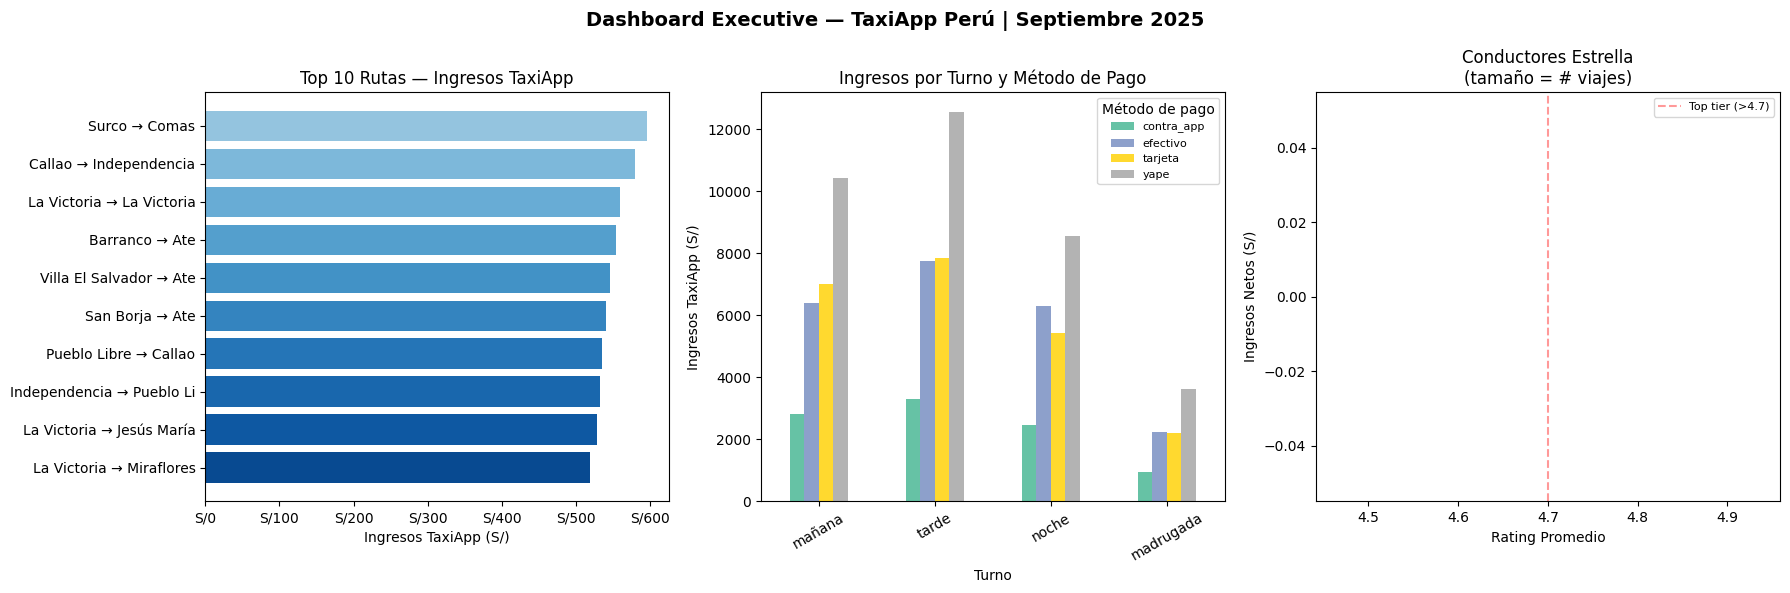

✅ Dashboard guardado


In [19]:
# ============================================================
# CELDA 5: Dashboard ejecutivo — 3 gráficos
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

gold_rutas = spark.read.parquet("/FileStore/taxi_lima/gold/top_rutas").toPandas()
gold_turno = spark.read.parquet("/FileStore/taxi_lima/gold/ingresos_turno_pago").toPandas()
gold_cond  = spark.read.parquet("/FileStore/taxi_lima/gold/conductores_estrella").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Dashboard Executive — TaxiApp Perú | Septiembre 2025", fontsize=14, fontweight="bold")

# Gráfico 1: Top 10 rutas por ingresos TaxiApp
axes[0].barh(gold_rutas["ruta"].str[:25], gold_rutas["ingresos_taxiapp"], color=plt.cm.Blues(np.linspace(0.4, 0.9, len(gold_rutas))))
axes[0].set_xlabel("Ingresos TaxiApp (S/)")
axes[0].set_title("Top 10 Rutas — Ingresos TaxiApp")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/{x:,.0f}"))
axes[0].invert_yaxis()

# Gráfico 2: Ingresos por turno (agrupado)
turnos_order = ["mañana", "tarde", "noche", "madrugada"]
turno_pivot  = gold_turno.pivot_table(index="turno", columns="metodo_pago", values="ingresos_taxiapp", aggfunc="sum", fill_value=0)
turno_pivot = turno_pivot.reindex([t for t in turnos_order if t in turno_pivot.index])
turno_pivot.plot(kind="bar", ax=axes[1], rot=30, colormap="Set2")
axes[1].set_title("Ingresos por Turno y Método de Pago")
axes[1].set_xlabel("Turno")
axes[1].set_ylabel("Ingresos TaxiApp (S/)")
axes[1].legend(title="Método de pago", fontsize=8)

# Gráfico 3: Conductores estrella — rating vs ingresos
axes[2].scatter(gold_cond["rating_prom"], gold_cond["ingresos_netos"], s=gold_cond["total_viajes"] * 2, c=gold_cond["rating_prom"], cmap="YlOrRd", alpha=0.8, edgecolors="gray")
for _, row in gold_cond.iterrows():
    axes[2].annotate(row["id_conductor"], (row["rating_prom"], row["ingresos_netos"]), fontsize=7, ha="center", va="bottom")
axes[2].set_xlabel("Rating Promedio")
axes[2].set_ylabel("Ingresos Netos (S/)")
axes[2].set_title("Conductores Estrella\n(tamaño = # viajes)")
axes[2].axvline(x=4.7, color="red", linestyle="--", alpha=0.4, label="Top tier (>4.7)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("dashboard_taxiapp.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard guardado")

##PARTE 3 — DESAFÍO: Simulación de Streaming (30 min)


In [20]:
# ============================================================
# CELDA 6: Structured Streaming — alertas de conductores
# Simular: detectar cuando un conductor tiene rating < 3.5
# en los últimos 5 viajes consecutivos
# ============================================================

# En Databricks: usar rate source como simulador de viajes llegando en tiempo real
stream_source = (
    spark.readStream
    .format("rate")
    .option("rowsPerSecond", 20)   # Simula 20 nuevos viajes por segundo
    .load()
)

# Transformar el stream: simular datos de viajes
stream_viajes = (
    stream_source
    .withColumn("id_conductor",
        F.concat(F.lit("CON"),
                 F.lpad((F.col("value") % 200 + 1).cast("string"), 4, "0")))
    .withColumn("rating_simulado",
        F.round(
            F.when(F.col("value") % 15 == 0, F.lit(2.8))  # Cada 15 viajes: rating bajo
             .otherwise(F.lit(4.0) + (F.col("value") % 10).cast("double") / 20),
            1
        ))
    .withColumn("tarifa_simulada",
        F.round(10 + (F.col("value") % 80).cast("double"), 2))
)

# Agregar en ventana de 30 segundos: detectar conductores con bajo rating
alertas_stream = (
    stream_viajes
    .groupBy(
        F.window(F.col("timestamp"), "30 seconds"),
        F.col("id_conductor")
    )
    .agg(
        F.count("*").alias("viajes_ventana"),
        F.round(F.avg("rating_simulado"), 2).alias("rating_prom_ventana"),
        F.round(F.sum("tarifa_simulada"), 2).alias("facturacion_ventana")
    )
    .filter(F.col("rating_prom_ventana") < 3.5)   # ← Solo conductores con bajo rating
    .select(
        F.col("window.start").alias("inicio_ventana"),
        F.col("window.end").alias("fin_ventana"),
        F.col("id_conductor"),
        F.col("viajes_ventana"),
        F.col("rating_prom_ventana"),
        F.col("facturacion_ventana"),
        F.lit("⚠️ ALERTA: Rating bajo — revisar conductor").alias("alerta")
    )
)

# Escribir a memoria para ver en tiempo real
query_alertas = (
    alertas_stream
    .writeStream
    .format("memory")
    .queryName("alertas_conductores")
    .outputMode("complete")
    .start()
)

# Ver las alertas durante 45 segundos
import time
print("🔴 SISTEMA DE ALERTAS EN TIEMPO REAL — TaxiApp Perú")
print("   Detectando conductores con rating < 3.5 en ventana de 30 segundos...")
print("-" * 70)

for ciclo in range(4):
    time.sleep(12)
    alertas = spark.sql("""
        SELECT id_conductor, viajes_ventana, rating_prom_ventana,
               facturacion_ventana, alerta
        FROM alertas_conductores
        ORDER BY rating_prom_ventana ASC
        LIMIT 5
    """)
    if alertas.count() > 0:
        print(f"\n[Ciclo {ciclo+1}/4 — {12*(ciclo+1)} seg]")
        alertas.show(truncate=False)
    else:
        print(f"  [Ciclo {ciclo+1}/4] Sin alertas aún...")

query_alertas.stop()
print("\n✅ Stream detenido. Sistema de alertas completado.")

🔴 SISTEMA DE ALERTAS EN TIEMPO REAL — TaxiApp Perú
   Detectando conductores con rating < 3.5 en ventana de 30 segundos...
----------------------------------------------------------------------
  [Ciclo 1/4] Sin alertas aún...

[Ciclo 2/4 — 24 seg]
+------------+--------------+-------------------+-------------------+------------------------------------------+
|id_conductor|viajes_ventana|rating_prom_ventana|facturacion_ventana|alerta                                    |
+------------+--------------+-------------------+-------------------+------------------------------------------+
|CON0196     |1             |2.8                |45.0               |⚠️ ALERTA: Rating bajo — revisar conductor|
|CON0181     |1             |2.8                |30.0               |⚠️ ALERTA: Rating bajo — revisar conductor|
|CON0101     |1             |2.8                |70.0               |⚠️ ALERTA: Rating bajo — revisar conductor|
|CON0131     |1             |2.8                |20.0               |⚠️ A

**Pregunta de reflexión 2: ¿Qué pasaría si aumentas rowsPerSecond a 1000? ¿El sistema de alertas seguiría funcionando igual? ¿Cuál sería el cuello de botella en Databricks Community (1 clúster)?**

#####R2: Al elevar el volumen a 1,000 registros por segundo, se gatillaría una acumulación de micro-batches pendientes debido a la velocidad de entrada (backpressure). El sistema no respondería en tiempo real sino con latencia progresiva.



**Pregunta de reflexión 3 (conexión con proyecto grupal): ¿Tu grupo podría aplicar Structured Streaming para detectar patrones en tiempo real en su proyecto? ¿Cuál sería la ventana temporal más adecuada?**

###### R3: Sí, en nuestro proyecto grupal es completamente viable implementar Structured Streaming para supervisar transacciones inusuales o fraudes en vivo. La ventana temporal recomendada sería una Ventana Deslizante (Sliding Window) de 10 minutos de duración con un intervalo de movimiento de 1 minuto
